In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="geemap.conversion")

In [2]:
import sys
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Para ver el entorno conda específico
import os
print(f"CONDA_DEFAULT_ENV: {os.environ.get('CONDA_DEFAULT_ENV', 'No conda env')}")

Python executable: /home/diego/miniconda3/envs/ndvi2gif_clean/bin/python
Python version: 3.9.23 | packaged by conda-forge | (main, Jun  4 2025, 17:57:12) 
[GCC 13.3.0]
CONDA_DEFAULT_ENV: ndvi2gif_clean


In [3]:
import ee
import geemap
import matplotlib.pyplot as plt
from ndvi2gif import NdviSeasonality
from ndvi2gif import NdviSeasonality
from ndvi2gif.timeseries import TimeSeriesAnalyzer, SpatialTrendAnalyzer
print("✓ Módulos importados correctamente")

# Authenticate & initialize Earth Engine
#ee.Authenticate()
ee.Initialize()

✓ Módulos importados correctamente


In [4]:
# Create interactive map
Map = geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [5]:
# Select an area that cover your area of interest
roi = Map.draw_last_feature

There we go again...
Using MODIS Terra + Aqua LST (maximum coverage)
Using all Sentinel-1 orbits (ascending + descending).
Applying S1 ARD preprocessing:
  - Speckle filter: REFINED_LEE
  - Terrain correction: True
  - Terrain model: VOLUME
Using point coordinates: (0.838838, 40.705826)
Extracting 48 temporal periods...
Progress: 48/48 (100.0%)
Successfully extracted 48 data points
Year 2018: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 289.0
Year 2019: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 258.0
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 290.0
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=35.0%, EOS=60.0%
EOS found at day 289.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 4/4 (100.0%)
Figure saved to rice_comprehensive.png


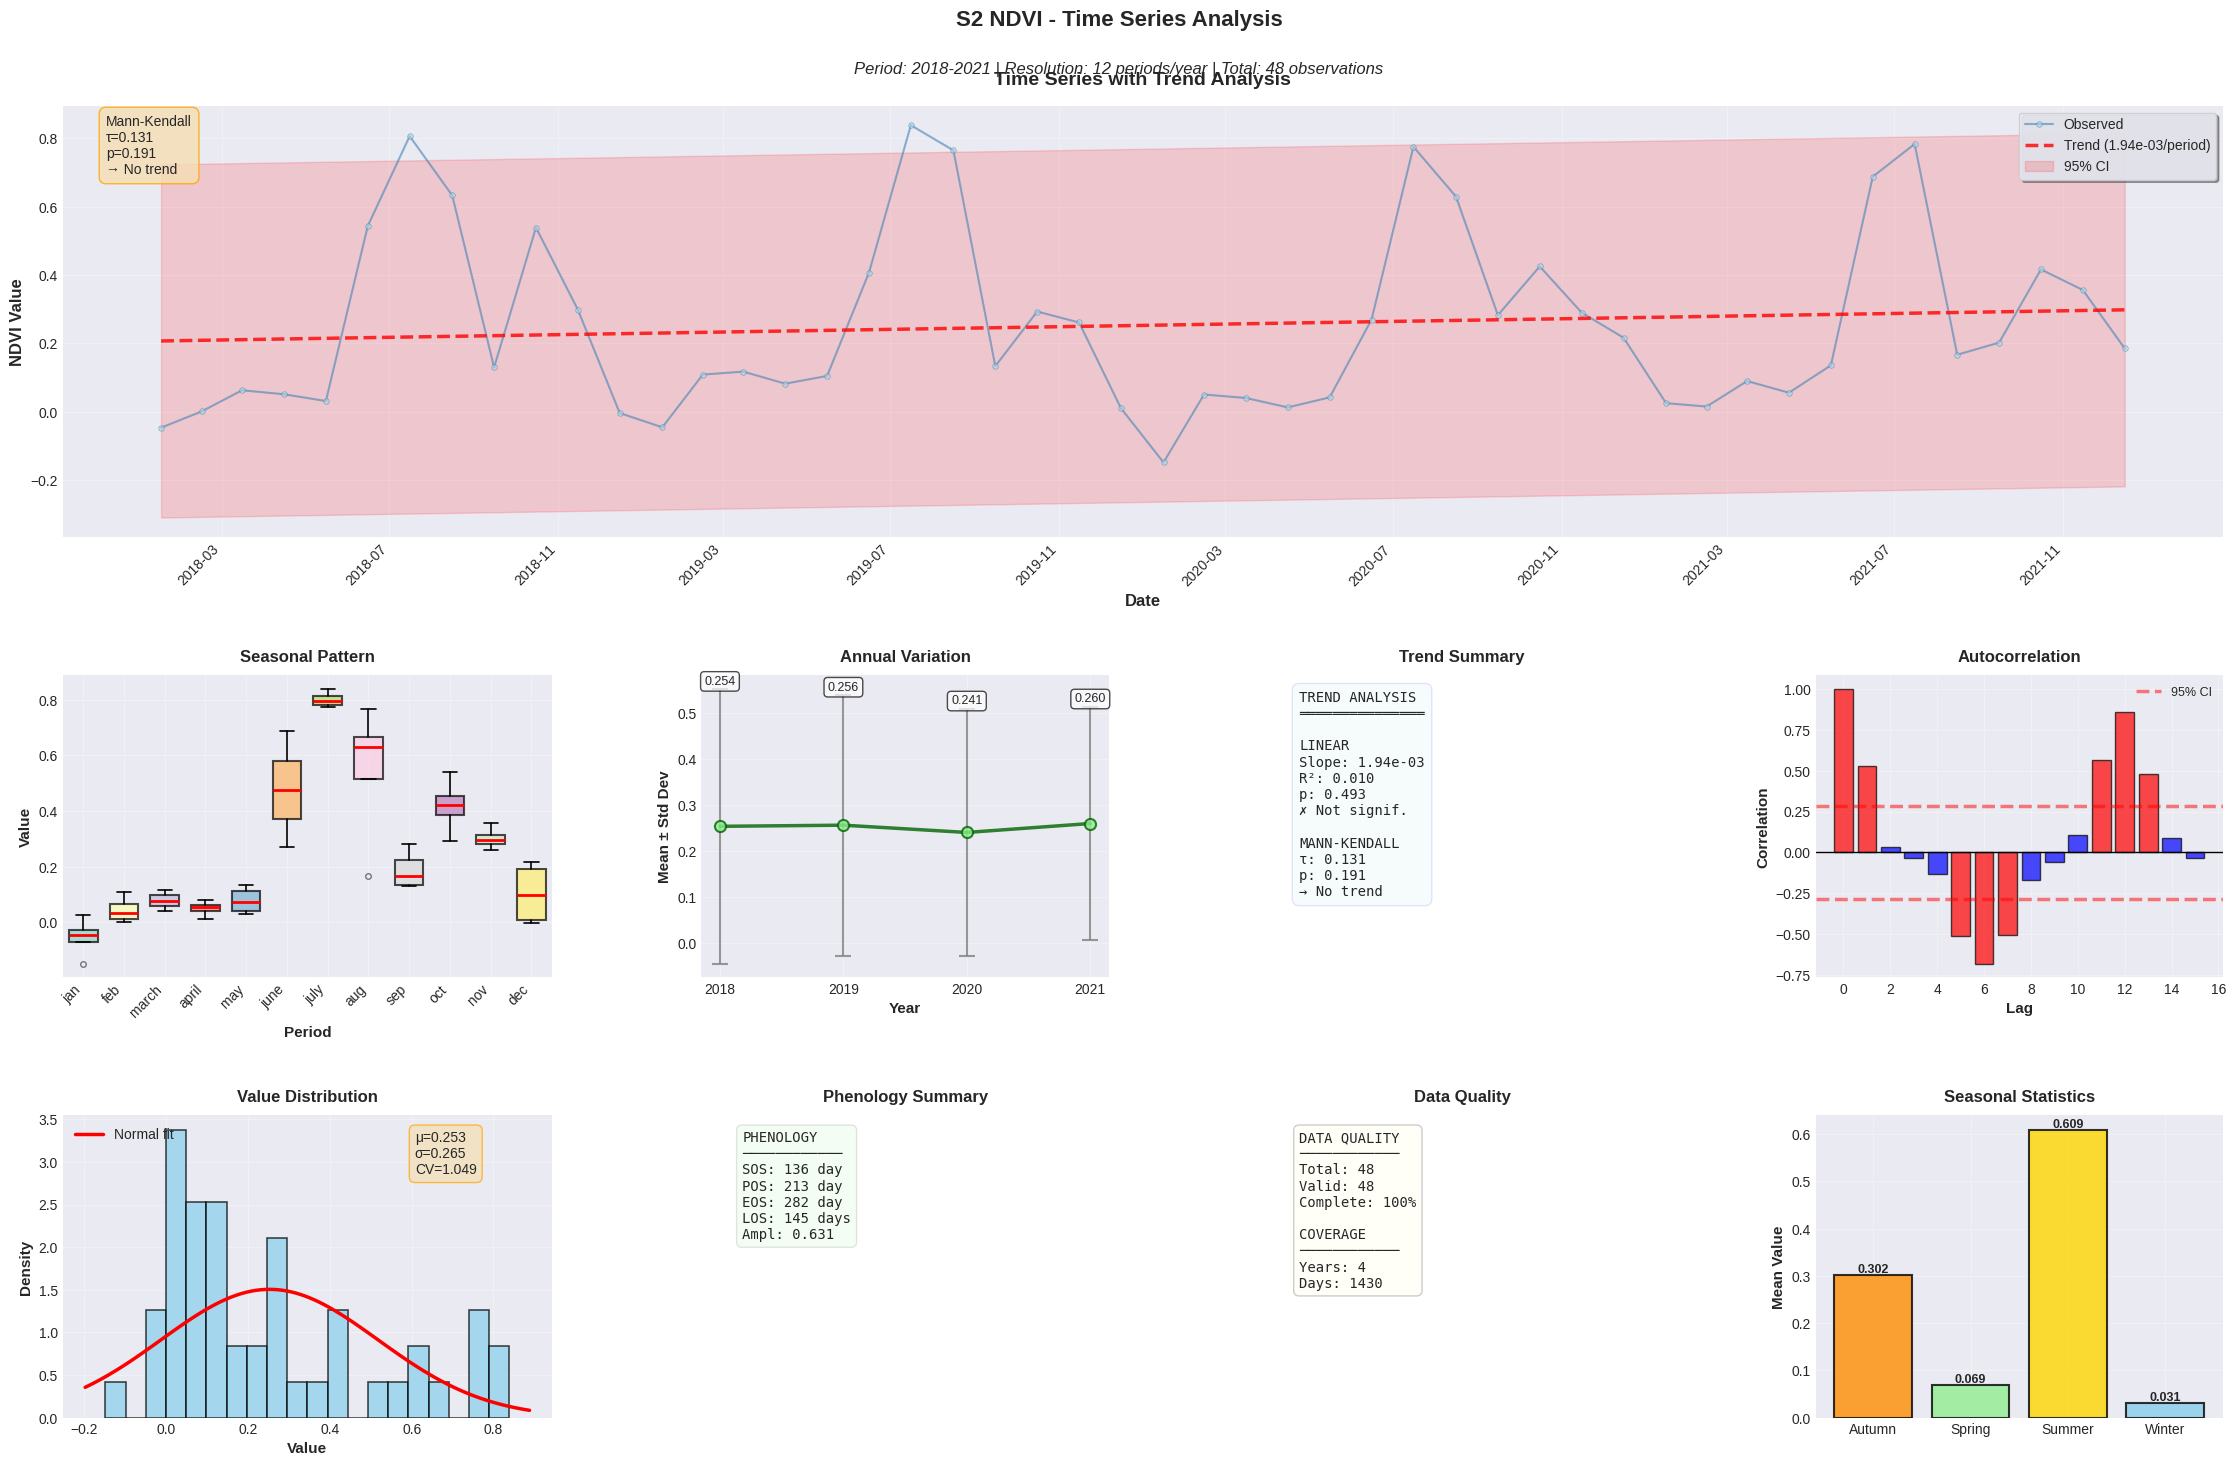

Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0
Year 2019: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 258.0
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 320.0
EOS found at day 320.0
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 4/4 (100.0%)
Phenological analysis saved to rice_phenology_threshold.png


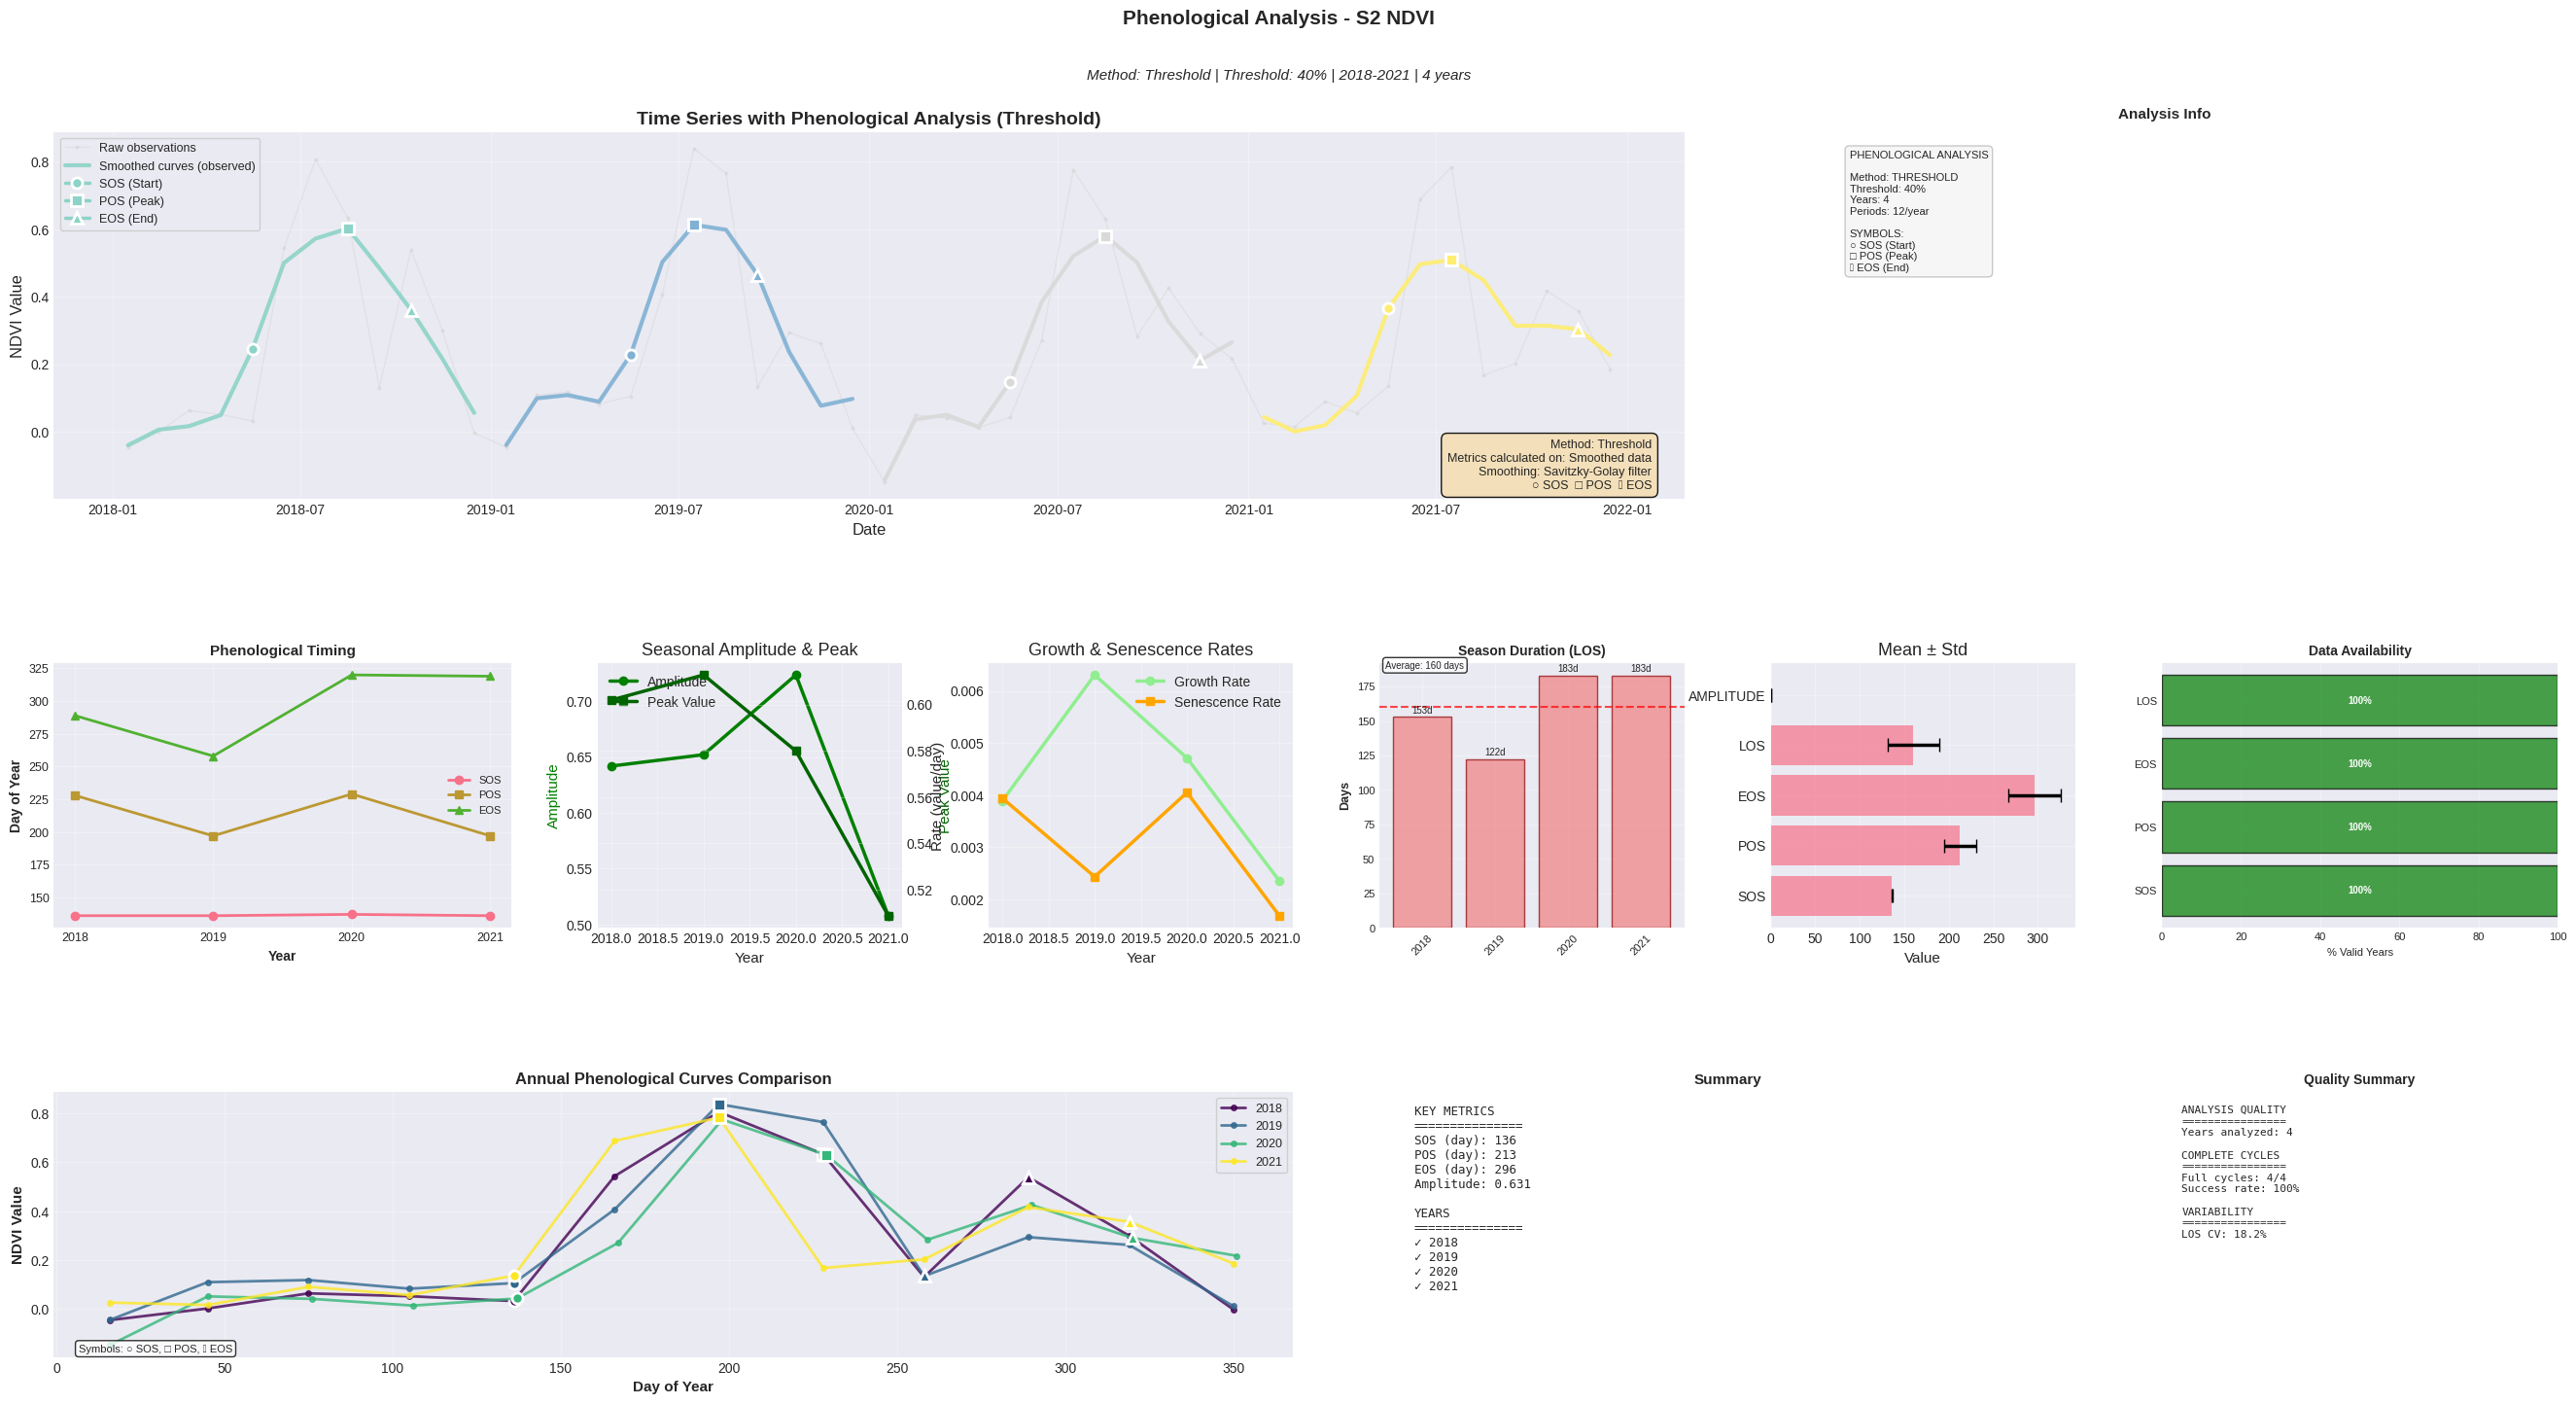

Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0010, neg=-0.0010
EOS found at day 258.0, 30.0 days after POS
Year 2019: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0010, neg=-0.0010
EOS found at day 228.0, 31.0 days after POS
Year 2020: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0010, neg=-0.0009
EOS found at day 259.0, 30.0 days after POS
Year 2021: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0007, neg=-0.0007
EOS found at day 228.0, 31.0 days after POS

PHENOLOGY EXTRACTION SUMMARY:
Method: derivative
Success rate: 4/4 (100.0%)
Phenological analysis saved to rice_phenology_derivative.png


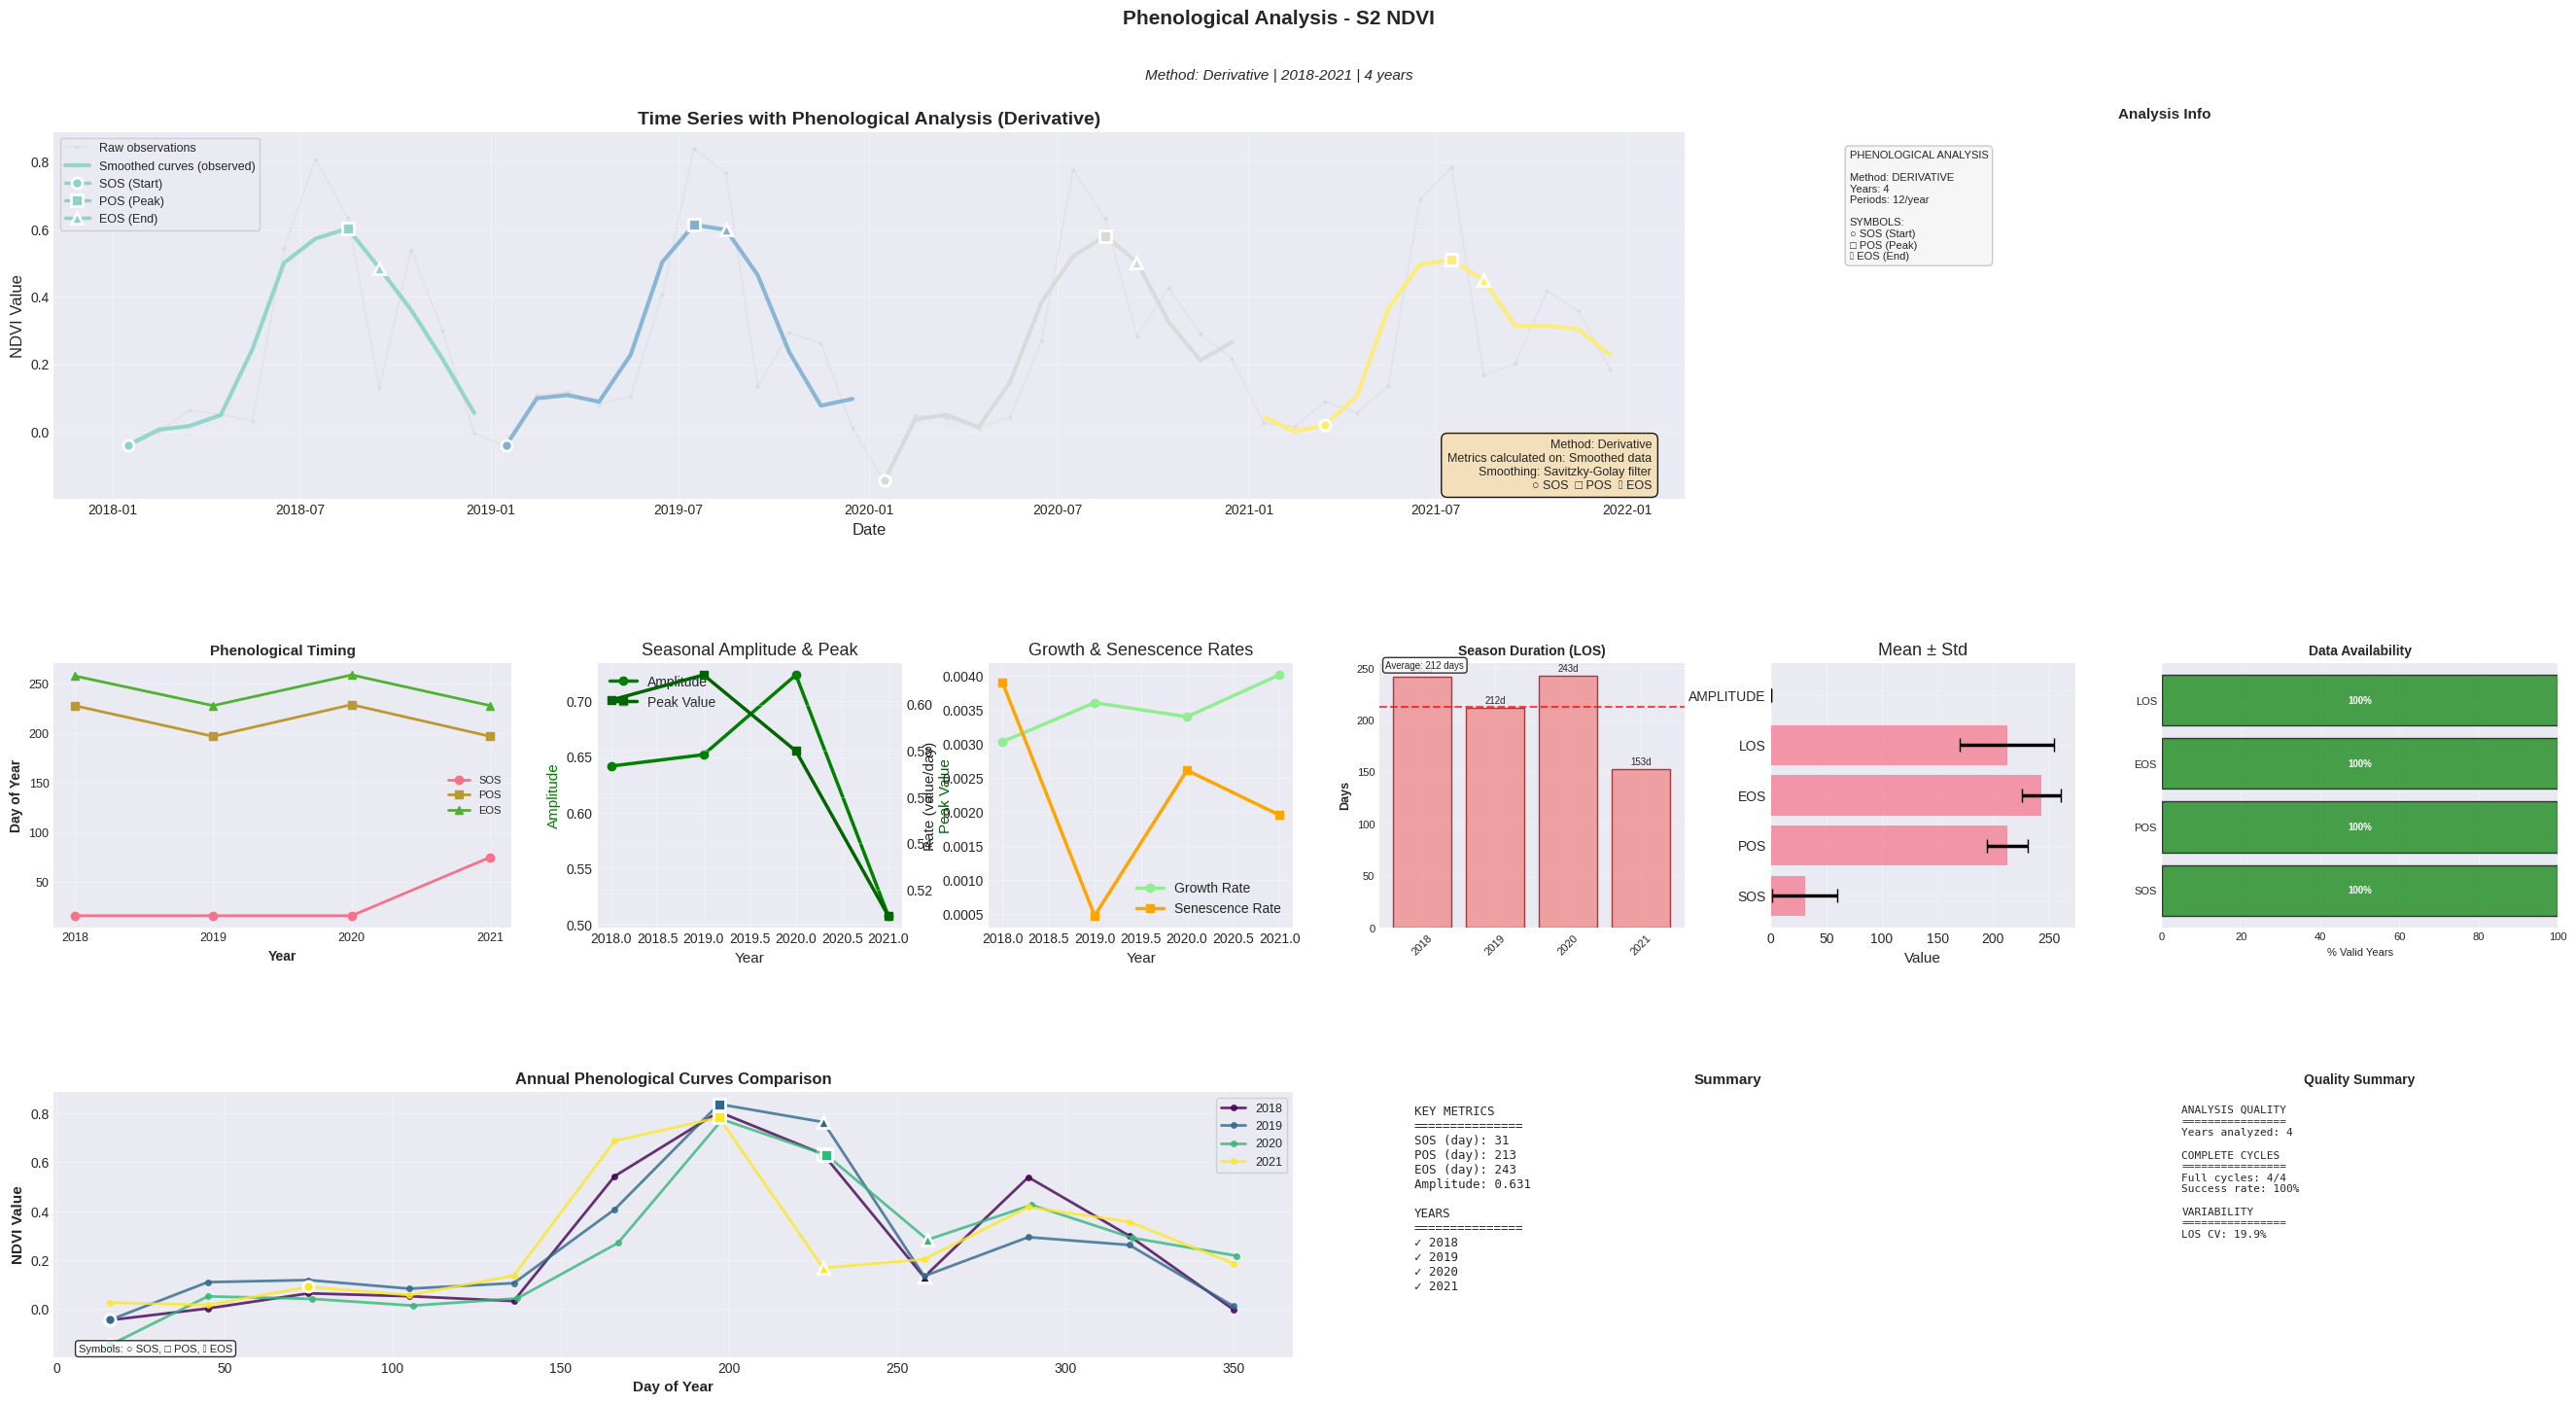

Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Logistic fit: R²=0.995, RMSE=0.0169, LOS=155.7 days
Year 2019: Applied smoothing (window=7, order=3)
Logistic fit: R²=0.974, RMSE=0.0352, LOS=123.5 days
Year 2020: Applied smoothing (window=7, order=3)
Logistic fit: R²=0.935, RMSE=0.0559, LOS=98.4 days
Year 2021: Applied smoothing (window=7, order=3)
Logistic fit: R²=0.984, RMSE=0.0220, LOS=86.8 days

PHENOLOGY EXTRACTION SUMMARY:
Method: logistic
Success rate: 4/4 (100.0%)
Phenological analysis saved to rice_phenology_logistic.png


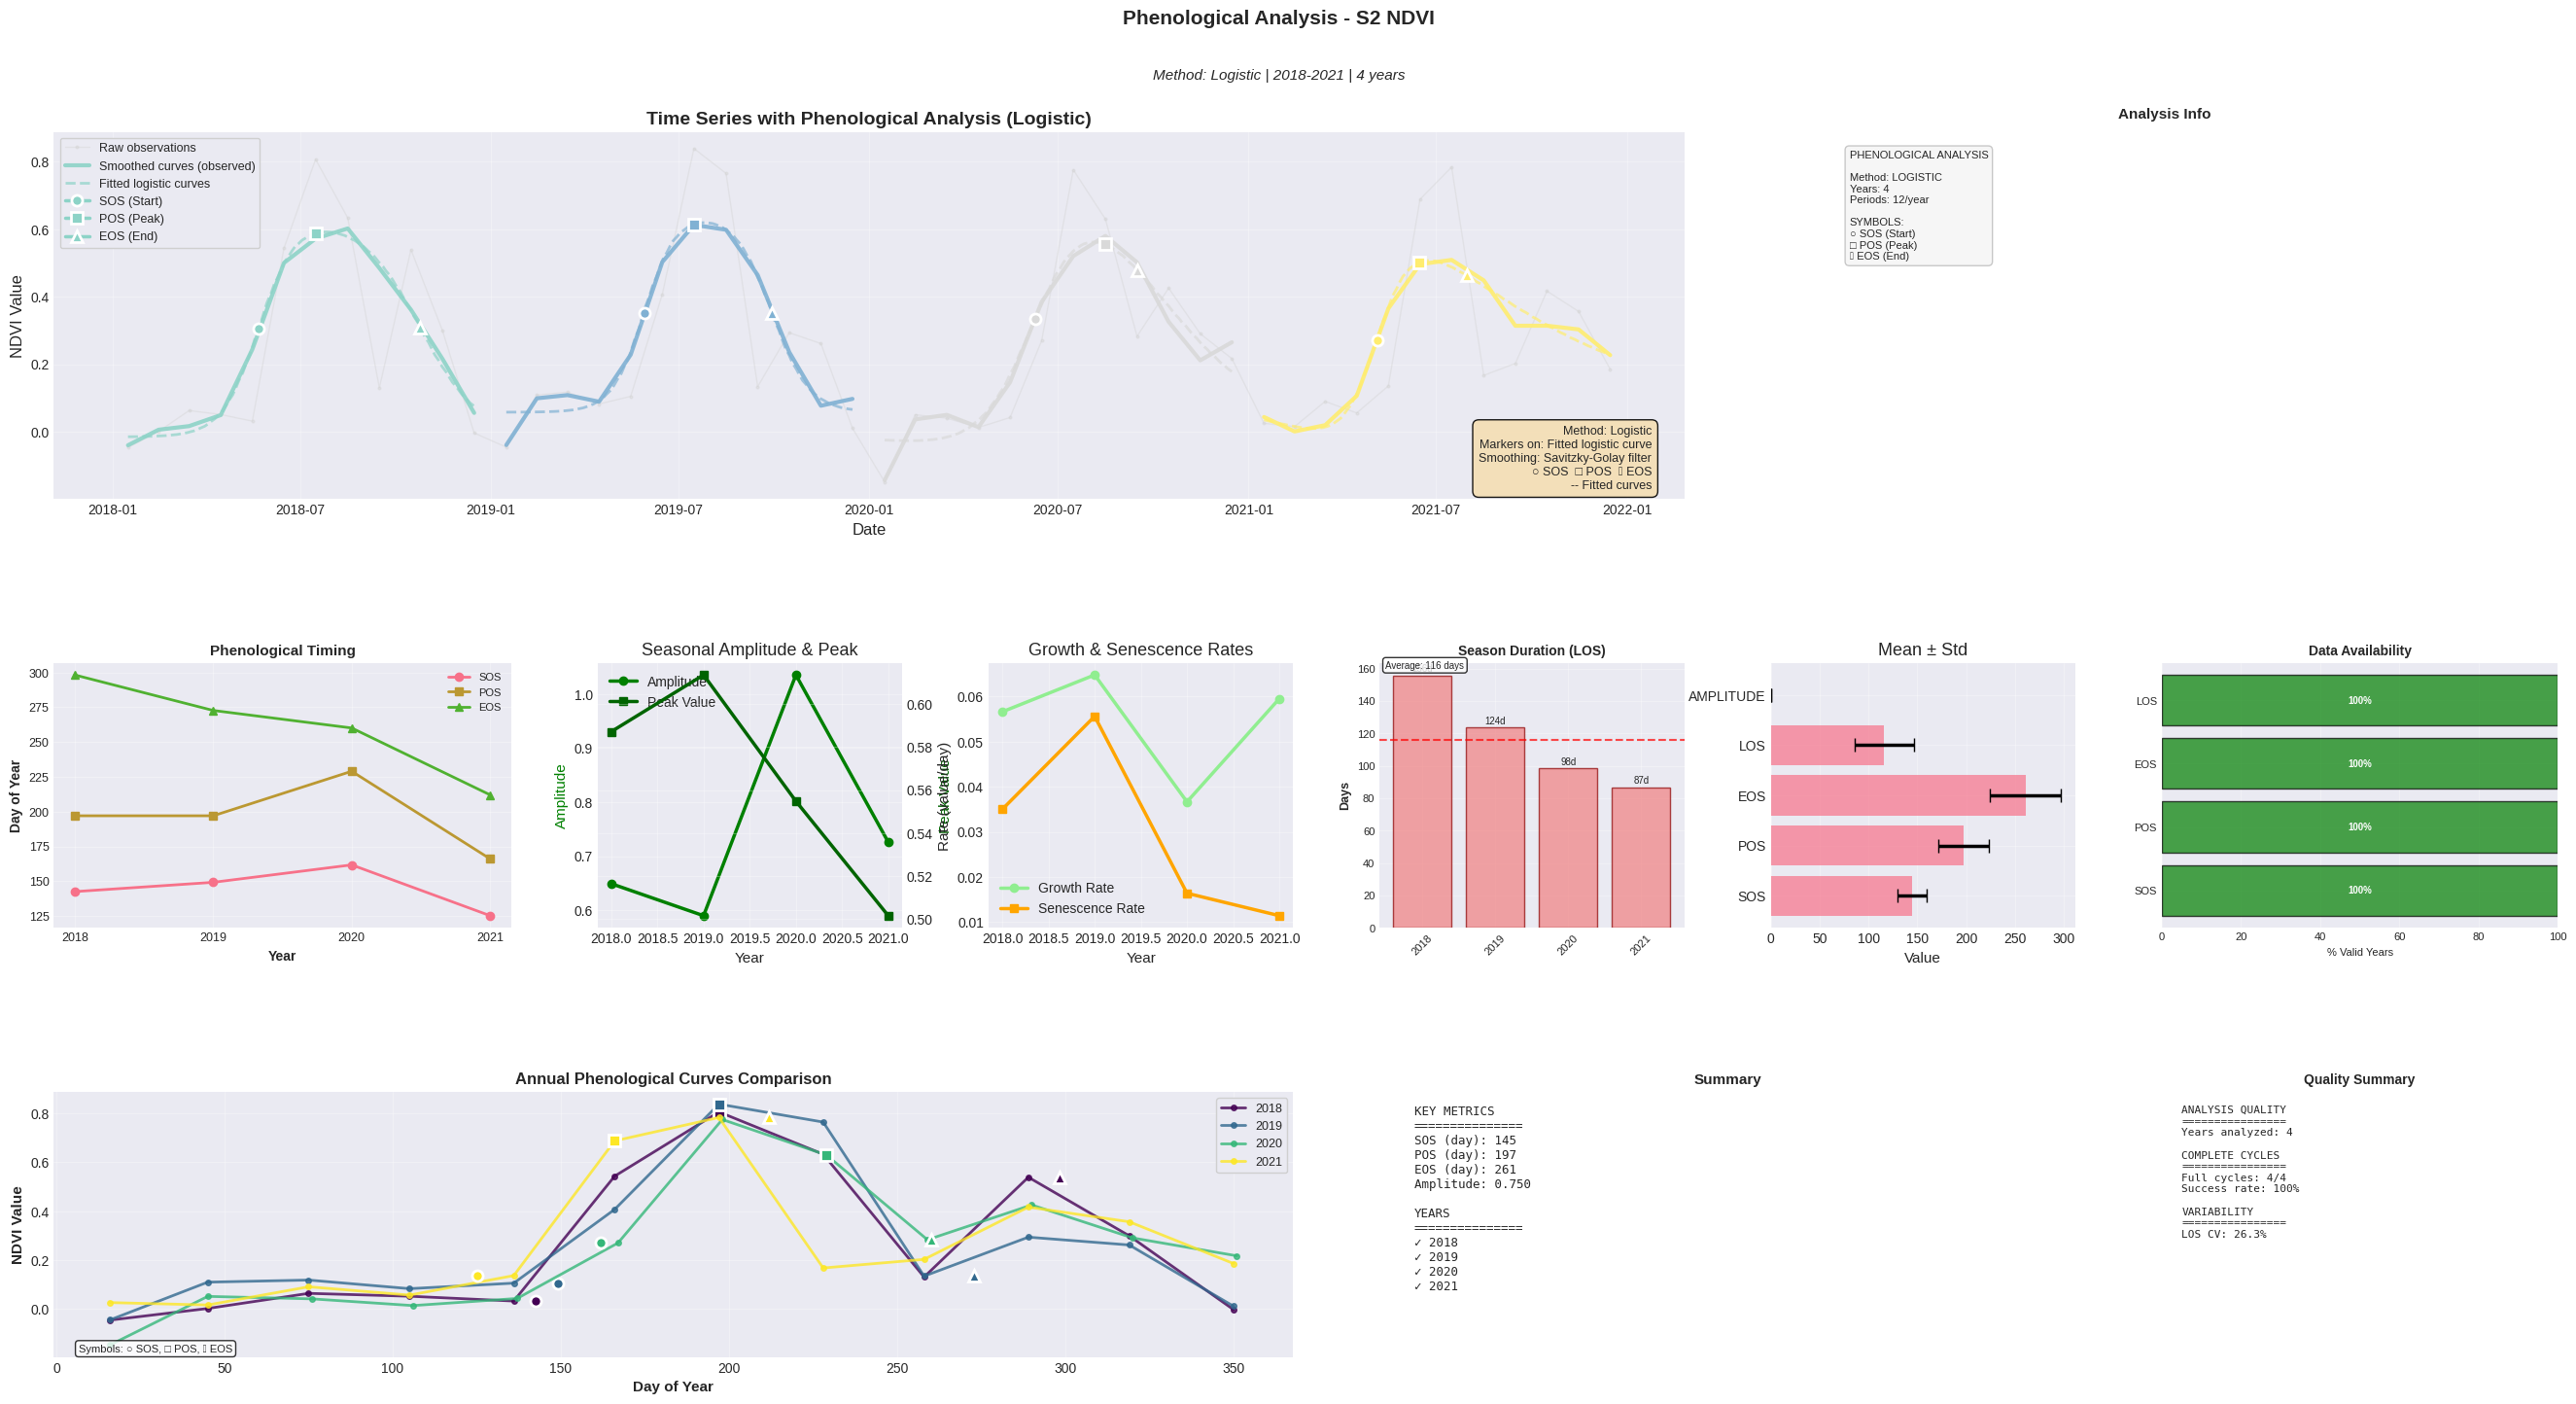

In [6]:
# Ejemplo completo con coordenadas de arroz optimizadas
import ee
import geemap
import numpy as np
import pandas as pd
from ndvi2gif import NdviSeasonality
from ndvi2gif.timeseries import TimeSeriesAnalyzer

ee.Initialize()

processor = NdviSeasonality(
    roi=roi,
    periods=12,
    start_year=2018,
    end_year=2022,
    sat='S2',
    index='ndvi',
    key='median'
)

ts_analyzer = TimeSeriesAnalyzer(processor)
isla_mayor = (-6.189970, 37.141442)
delta_del_ebro = (0.838838, 40.705826)
palencia = (-5.676501, 42.418859)
lebrija = (-6.063629, 36.985864)
california = (-119.422422, 35.643278)

# 1. Análisis comprensivo (1 gráfico)
fig1 = ts_analyzer.plot_comprehensive_analysis(
    point=delta_del_ebro,
    figsize=(24, 16),
    save_path='rice_comprehensive.png'
)

# 2. Análisis fenológico threshold (1 gráfico)
fig2 = ts_analyzer.plot_phenology_analysis(
    point=delta_del_ebro,
    method='threshold',
    threshold_percentile=40,
    figsize=(28, 18),
    save_path='rice_phenology_threshold.png'
)

# 3. Análisis fenológico derivative (1 gráfico)
fig3 = ts_analyzer.plot_phenology_analysis(
    point=delta_del_ebro,
    method='derivative',
    figsize=(28, 18),
    save_path='rice_phenology_derivative.png'
)

# 3. Análisis fenológico derivative (1 gráfico)
fig4 = ts_analyzer.plot_phenology_analysis(
    point=delta_del_ebro,
    method='logistic',
    figsize=(28, 18),
    save_path='rice_phenology_logistic.png'
)

In [7]:
# ========== COMPARACIÓN IMPACTO DEL SUAVIZADO ==========
comparison = ts_analyzer.compare_smoothing_impact(
    point=delta_del_ebro,
    method='threshold', 
    threshold_percentile=40
)

print(comparison['summary'])

Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0
Year 2019: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 258.0
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 320.0
EOS found at day 320.0
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 4/4 (100.0%)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 228.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 290.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 4/4 (100.0%)
SMOOTHING IMPACT SUMMARY
SOS:
  Mean change: -30.00 

Ejecutando comparación de suavizado...
Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0
Year 2019: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 258.0
Year 2020: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS detected using value drop method at day 320.0
EOS found at day 320.0
Year 2021: Applied smoothing (window=7, order=3)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 319.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 4/4 (100.0%)
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 228.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 290.0
Adaptive thresholds: SOS=28.0%, EOS=48.0%
EOS found at day 289.0

PHENOLOGY EXTRACTION SUMMARY:
Method: threshold
Success rate: 4/4 (100.0%)

RESUMEN DEL 

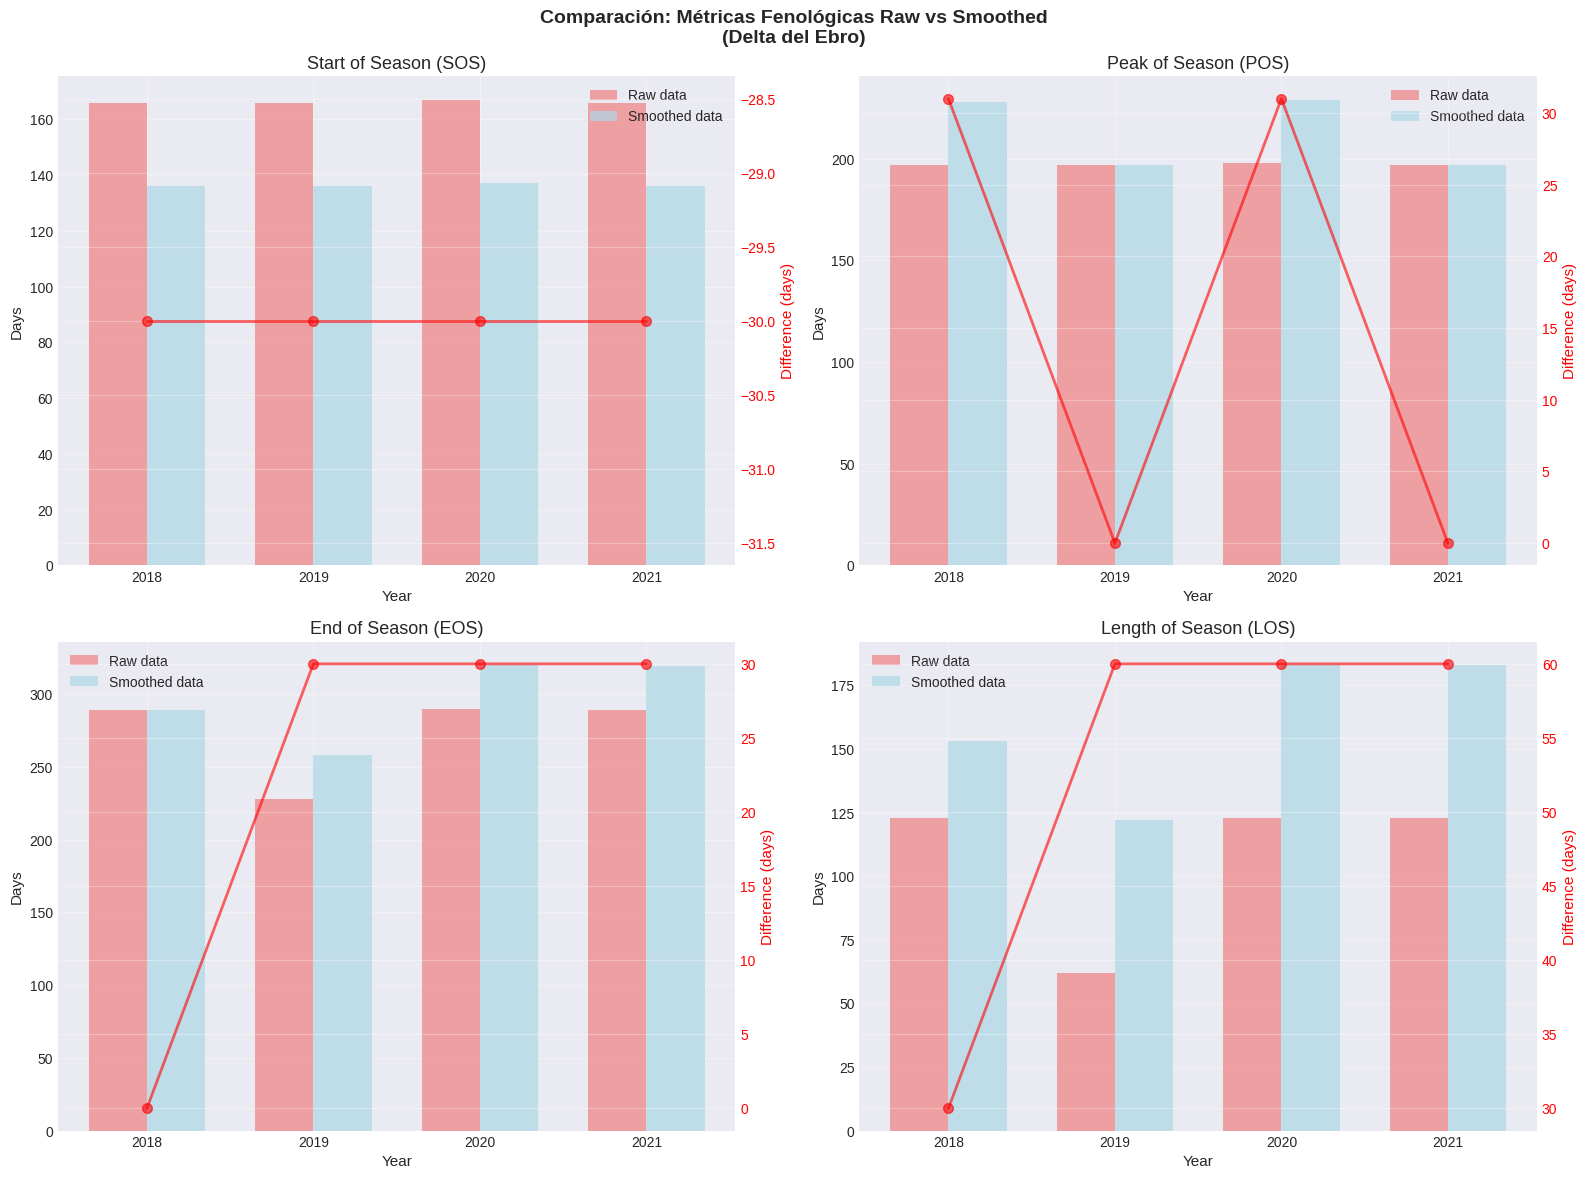


COMPARACIÓN MÉTODO DERIVATIVE
Using cached time series data
Year 2018: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0010, neg=-0.0010
EOS found at day 258.0, 30.0 days after POS
Year 2019: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0010, neg=-0.0010
EOS found at day 228.0, 31.0 days after POS
Year 2020: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0010, neg=-0.0009
EOS found at day 259.0, 30.0 days after POS
Year 2021: Applied smoothing (window=7, order=3)
Derivative thresholds: pos=0.0007, neg=-0.0007
EOS found at day 228.0, 31.0 days after POS

PHENOLOGY EXTRACTION SUMMARY:
Method: derivative
Success rate: 4/4 (100.0%)
Derivative thresholds: pos=0.0017, neg=-0.0017
EOS found at day 228.0, 31.0 days after POS
Derivative thresholds: pos=0.0017, neg=-0.0017
EOS found at day 228.0, 31.0 days after POS
Derivative thresholds: pos=0.0013, neg=-0.0013
EOS found at day 229.0, 31.0 days after POS
Derivative thresholds: pos=0.

In [8]:
# ========== COMPARACIÓN IMPACTO DEL SUAVIZADO ==========

# Ejecutar la comparación
print("Ejecutando comparación de suavizado...")
comparison = ts_analyzer.compare_smoothing_impact(
    point=delta_del_ebro,
    method='threshold', 
    threshold_percentile=40
)

# Mostrar resumen cuantitativo
print("\n" + "="*50)
print("RESUMEN DEL IMPACTO DEL SUAVIZADO")
print("="*50)
print(comparison['summary'])

# Análisis detallado por año
print("\n" + "="*50)
print("DIFERENCIAS DETALLADAS POR AÑO")
print("="*50)

for year in sorted(comparison['differences'].keys()):
    print(f"\nAÑO {year}:")
    year_diff = comparison['differences'][year]
    
    for metric, data in year_diff.items():
        raw_val = data['raw']
        smooth_val = data['smoothed']
        diff = data['difference']
        rel_change = data['relative_change']
        
        print(f"  {metric.upper():<12}: "
              f"Raw={raw_val:6.1f}, "
              f"Smoothed={smooth_val:6.1f}, "
              f"Diff={diff:+5.1f} días "
              f"({rel_change:+4.1f}%)")

# Estadísticas agregadas
print("\n" + "="*50) 
print("ESTADÍSTICAS AGREGADAS")
print("="*50)

all_diffs = {}
for year_data in comparison['differences'].values():
    for metric, data in year_data.items():
        if metric not in all_diffs:
            all_diffs[metric] = []
        if not np.isnan(data['difference']):
            all_diffs[metric].append(data['difference'])

for metric, diffs in all_diffs.items():
    if diffs:
        mean_diff = np.mean(diffs)
        std_diff = np.std(diffs)
        max_abs_diff = np.max(np.abs(diffs))
        
        print(f"{metric.upper():<12}: "
              f"Media={mean_diff:+5.2f}±{std_diff:4.2f} días, "
              f"Max={max_abs_diff:5.2f} días")

# Crear gráfico comparativo
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparación: Métricas Fenológicas Raw vs Smoothed\n(Delta del Ebro)', 
             fontsize=14, fontweight='bold')

metrics_to_plot = ['sos', 'pos', 'eos', 'los']
metric_labels = ['Start of Season (SOS)', 'Peak of Season (POS)', 
                'End of Season (EOS)', 'Length of Season (LOS)']

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx//2, idx%2]
    
    # Extraer datos
    years = []
    raw_vals = []
    smooth_vals = []
    
    for year in sorted(comparison['differences'].keys()):
        if metric in comparison['differences'][year]:
            years.append(year)
            raw_vals.append(comparison['differences'][year][metric]['raw'])
            smooth_vals.append(comparison['differences'][year][metric]['smoothed'])
    
    if years:
        x = np.arange(len(years))
        width = 0.35
        
        # Barras comparativas
        ax.bar(x - width/2, raw_vals, width, label='Raw data', 
               alpha=0.7, color='lightcoral')
        ax.bar(x + width/2, smooth_vals, width, label='Smoothed data', 
               alpha=0.7, color='lightblue')
        
        # Configuración
        ax.set_xlabel('Year')
        ax.set_ylabel('Days' if metric != 'los' else 'Days')
        ax.set_title(label)
        ax.set_xticks(x)
        ax.set_xticklabels(years)
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Diferencias como línea
        ax2 = ax.twinx()
        diffs = [smooth_vals[i] - raw_vals[i] for i in range(len(years))]
        ax2.plot(x, diffs, 'ro-', alpha=0.6, linewidth=2, 
                label='Difference (Smoothed - Raw)')
        ax2.set_ylabel('Difference (days)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')

plt.tight_layout()
plt.savefig('phenology_comparison_raw_vs_smoothed.png', dpi=300, bbox_inches='tight')
plt.show()

# Comparar también con método derivative
print("\n" + "="*70)
print("COMPARACIÓN MÉTODO DERIVATIVE")
print("="*70)

comparison_deriv = ts_analyzer.compare_smoothing_impact(
    point=delta_del_ebro,
    method='derivative'
)

print(comparison_deriv['summary'])